In [1]:
%matplotlib inline

import os, warnings

import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct
import networkx as nx

import torch
from src.utils import get_weight_masks, get_weight_masks_schaefer, get_file_str, normalize_x

# import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
save_figs = True

In [3]:
# directories
# tracto_string = 'deterministic_count'
# tracto_string = 'deterministic_ncount'
# tracto_string = 'deterministic_mean_length'
# tracto_string = 'deterministic_gfa'

tracto_string = 'probabilistic_sift_radius2_count'
# tracto_string = 'probabilistic_sift_invnodevol_radius2_count'
# tracto_string = 'probabilistic_radius2_count'
# tracto_string = 'probabilistic_radius2_meanlength'
datadir = '/home/lindenmp/research_projects/neuro_rnn/data/{0}'.format(tracto_string)
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'
# task = 'MultiSensoryIntegration-v0'
# task = 'ContextDecisionMaking-v0'
dt = 100
batch_size = 32
decision = 300
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len_multi = 5
seq_len = seq_len * seq_len_multi
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 30000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.0015
mask_weights = True
kernel_type = 'sa_axis'
# kernel_type = 'euclidean'
# kernel_type = None

if mask_weights and hidden_size == 50:
    n_io = '9-13'
if mask_weights and hidden_size == 100:
    n_io = '14-27'
if mask_weights and hidden_size == 200:
    n_io = '31-52'

120


In [4]:
# dataset = 'pnc'
# dataset = 'hbn_1'
dataset = 'hbn_3'
# dataset = 'all'

which_feature = 'edge'
# which_feature = 'strength'

In [5]:
timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'reg_type': reg_type, 'reg_weight': reg_weight, 'kernel_type': kernel_type, # regularization parameters
    'env_kwargs': env_kwargs,
}

In [6]:
# weight masks
if mask_weights:
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    centroids = centroids[:hidden_size]
    roi_names = list(centroids['ROI Name'])
    input_system = 'Vis'
    output_system = 'Default'
    masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io

# file_str = get_file_str(config, standard=False)
file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-120-300_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.0015-sa_axis


In [7]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [8]:
# load data
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
training_loss = log_args['training_loss']
validation_loss = log_args['validation_loss']
test_accuracy = log_args['test_accuracy']
n_logged_epochs = test_accuracy.shape[-1]

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']
del checkpoint

x_start = 1
test_accuracy = test_accuracy[:, x_start:201]
hidden_weights = hidden_weights[:, x_start:201]
n_logged_epochs = test_accuracy.shape[-1]
n_epochs = (test_accuracy.shape[1] - 1) * 100
x_step = int(n_epochs / (n_logged_epochs-1))

print(training_loss.shape)
print(validation_loss.shape)
print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs, n_epochs)

(25, 30000)
(25, 30000)
(25, 200)
(25, 200, 100, 100)
200 19900


In [9]:
# f, ax = plt.subplots(1, 1, figsize=(5, 5))
# this_mat = hidden_weights.mean(axis=0)[-1]
# sns.heatmap(np.log(this_mat), ax=ax, square=True)

In [10]:
# np.abs(np.linalg.eigvals(this_mat))

### Connectome weights

In [11]:
n_parcels = int(hidden_size * 2)

A_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('pnc', n_parcels))
A_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('pnc', n_parcels))
A_pnc = A_pnc[:hidden_size, :hidden_size, :]
Am_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format('pnc', n_parcels))
Am_pnc = Am_pnc[:hidden_size, :hidden_size]
df_pnc = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format('pnc', n_parcels), index_col=0)

A_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_A.npy').format('hbn', n_parcels))
A_hbn = A_hbn[:hidden_size, :hidden_size, :]
Am_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format('hbn', n_parcels))
Am_hbn = Am_hbn[:hidden_size, :hidden_size]
df_hbn = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format('hbn', n_parcels), index_col=0)

In [12]:
if dataset == 'pnc':
    Am_human = Am_pnc
    A_human = A_pnc
    df_human = df_pnc
elif dataset == 'hbn_1':
    Am_human = Am_hbn
    A_human = A_hbn
    df_human = df_hbn
    df_human = df_human[df_hbn['study_site'] == 'HBN-1']
    A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-1']
elif dataset == 'hbn_3':
    Am_human = Am_hbn
    A_human = A_hbn
    df_human = df_hbn
    df_human = df_human[df_hbn['study_site'] == 'HBN-3']
    A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-3']
else:
    Am_human = (Am_pnc + Am_hbn) / 2
    cols = ['age', 'sex', 'study', 'study_site']
    df_human = pd.concat((df_pnc[cols], df_hbn[cols]), axis=0)
    A_human = np.concatenate((A_pnc, A_hbn), axis=2)
    # df_human = pd.concat((df_pnc[cols], df_hbn[df_hbn['study_site'] == 'HBN-3'][cols]), axis=0)
    # A_human = np.concatenate((A_pnc, A_hbn[:, :, df_hbn['study_site'] == 'HBN-3']), axis=2)

print(A_human.shape, df_human.shape)
print(df_human['age'].describe())
n_subjects = A_human.shape[-1]

(100, 100, 510) (510, 4)
count    510.000000
mean      11.336514
std        3.364671
min        5.838923
25%        8.647957
50%       10.750113
75%       13.607574
max       21.216746
Name: age, dtype: float64


<Axes: >

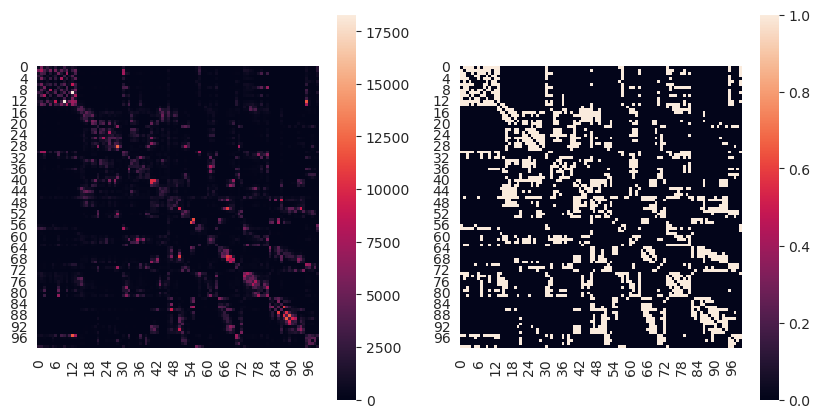

In [13]:
thresh = np.quantile(Am_human, q=0.8)
mask = Am_human > thresh
Am_human_thresh = Am_human.copy()
Am_human_thresh[mask] = 1
Am_human_thresh[~mask] = 0
np.fill_diagonal(Am_human_thresh, 0)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(Am_human, ax=ax[0], square=True)
sns.heatmap(Am_human_thresh, ax=ax[1], square=True)

In [14]:
subj_filter = np.zeros(n_subjects).astype(bool)
for i in np.arange(n_subjects):
    if np.all(A_human[:, :, i] == 0):
        subj_filter[i] = True

    if np.any(np.isnan(A_human[:, :, i])):
        subj_filter[i] = True

    if np.any(np.isinf(A_human[:, :, i])):
        subj_filter[i] = True

    if np.std(A_human[:, :, i]) == 0:
        subj_filter[i] = True

    if bct.density_und(A_human[:,:,i])[0] < .001:
        subj_filter[i] = True

In [15]:
if np.any(subj_filter):
    df_human = df_human[~subj_filter]
    A_human = A_human[:, :, ~subj_filter]
    print(A_human.shape, df_human.shape)
    print(df_human['age'].describe())
    n_subjects = A_human.shape[-1]

### RNN weights

# Stats

In [16]:
from numba import njit

@njit
def get_mean(x):
    n = len(x)
    m = np.empty(n)
    for i in range(n):
        m[i] = x[i].mean()
    return m

@njit
def get_std(x):
    n = len(x)
    s = np.empty(n)
    for i in range(n):
        s[i] = x[i].std()
    return s

@njit
def get_corr_fast(x, y):
    ''' Correlation '''
    n, k = x.shape
    m, k = y.shape

    mu_a = get_mean(x)
    mu_b = get_mean(y)
    sig_a = get_std(x)
    sig_b = get_std(y)

    corr_coef = np.empty((n, m))

    for i in range(n):
        for j in range(m):
            corr_coef[i, j] = (x[i] - mu_a[i]) @ (y[j] - mu_b[j]) / k / sig_a[i] / sig_b[j]

    return corr_coef

In [17]:
df_human['age_group'] = np.zeros(n_subjects)
n_quantiles = 10
quantiles = np.linspace(0, 1, n_quantiles+1)[1:]
print(quantiles)
for i, q in enumerate(quantiles):
    thresh = np.quantile(df_human['age'], q=q)
    if i == 0:
        mask = df_human['age'] <= thresh
    else:
        mask = np.logical_and(df_human['age'] <= thresh, df_human['age'] > previous_thresh)
    df_human.loc[mask, 'age_group'] = i
    previous_thresh = thresh

print(df_human.groupby('age_group')['age'].count())
print(df_human.groupby('age_group')['age'].mean())

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
age_group
0.0    51
1.0    51
2.0    51
3.0    51
4.0    51
5.0    51
6.0    51
7.0    51
8.0    51
9.0    51
Name: age, dtype: int64
age_group
0.0     6.884793
1.0     7.820480
2.0     8.670972
3.0     9.355184
4.0    10.169144
5.0    11.253761
6.0    12.274603
7.0    13.672339
8.0    15.363666
9.0    17.900202
Name: age, dtype: float64


/tmp/ipykernel_75902/3138579801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_human['age_group'] = np.zeros(n_subjects)


In [18]:
if which_feature == 'edge':
    # weight_mask = Am_human > 0
    weight_mask = Am_human_thresh > 0
    # weight_mask = Am_human[masks['bystanders_bystanders']] > 0
    n_features = np.sum(weight_mask)
    print(n_features)
    rnn_features = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            A = (A + A.T) / 2
            # A = A[masks['bystanders_bystanders']]
            A = A[weight_mask]
            rnn_features[run, epoch, :] = A
            rnn_features[run, epoch, :] = sp.stats.rankdata(rnn_features[run, epoch, :])

    human_features = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        # A = A[masks['bystanders_bystanders']]
        A = A[weight_mask]
        human_features[subj, :] = A
        human_features[subj, :] = sp.stats.rankdata(human_features[subj, :])

elif which_feature == 'strength':
    n_features = hidden_size
    # n_features = np.sum(masks['bystanders'])
    rnn_features = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            np.fill_diagonal(A, 0)
            A = (A + A.T) / 2
            # retain only bystanders
            # A = A[masks['bystanders_bystanders']]
            # A = A.reshape(np.sum(masks['bystanders']), np.sum(masks['bystanders']))

            rnn_features[run, epoch, :] = bct.strengths_und(A)
            rnn_features[run, epoch, :] = sp.stats.rankdata(rnn_features[run, epoch, :])

    human_features = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        np.fill_diagonal(A, 0)
        # retain only bystanders
        # A = A[masks['bystanders_bystanders']]
        # A = A.reshape(np.sum(masks['bystanders']), np.sum(masks['bystanders']))

        human_features[subj, :] = bct.strengths_und(A)
        human_features[subj, :] = sp.stats.rankdata(human_features[subj, :])

feature_corr = np.zeros((n_runs, n_logged_epochs, n_subjects))
for run in tqdm(np.arange(n_runs)):
    feature_corr[run] = get_corr_fast(rnn_features[run, :, :], human_features)
feature_corr_mean = np.mean(feature_corr, axis=0)

feature_corr_mean_group = np.zeros((n_logged_epochs, n_quantiles))
for group in np.arange(n_quantiles):
    feature_corr_mean_group[:, group] = np.mean(feature_corr_mean[:, df_human['age_group'] == group], axis=1)

print(rnn_features.shape, human_features.shape)
print(feature_corr.shape, feature_corr_mean_group.shape)

1904


100%|██████████| 25/25 [00:02<00:00, 11.46it/s]

(25, 200, 1904) (510, 1904)
(25, 200, 510) (200, 10)


In [19]:
age_corr = np.zeros((n_runs, n_logged_epochs))
for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        age_corr[run, epoch] = sp.stats.spearmanr(df_human['age'], feature_corr[run, epoch])[0]

age_corr_mean = np.zeros(n_logged_epochs)
for epoch in tqdm(np.arange(n_logged_epochs)):
    age_corr_mean[epoch] = sp.stats.spearmanr(df_human['age'], feature_corr_mean[epoch])[0]

print(age_corr.shape, age_corr_mean.shape)

100%|██████████| 200/200 [00:00<00:00, 5449.38it/s]

(25, 200) (200,)


[  2  65 127 190]


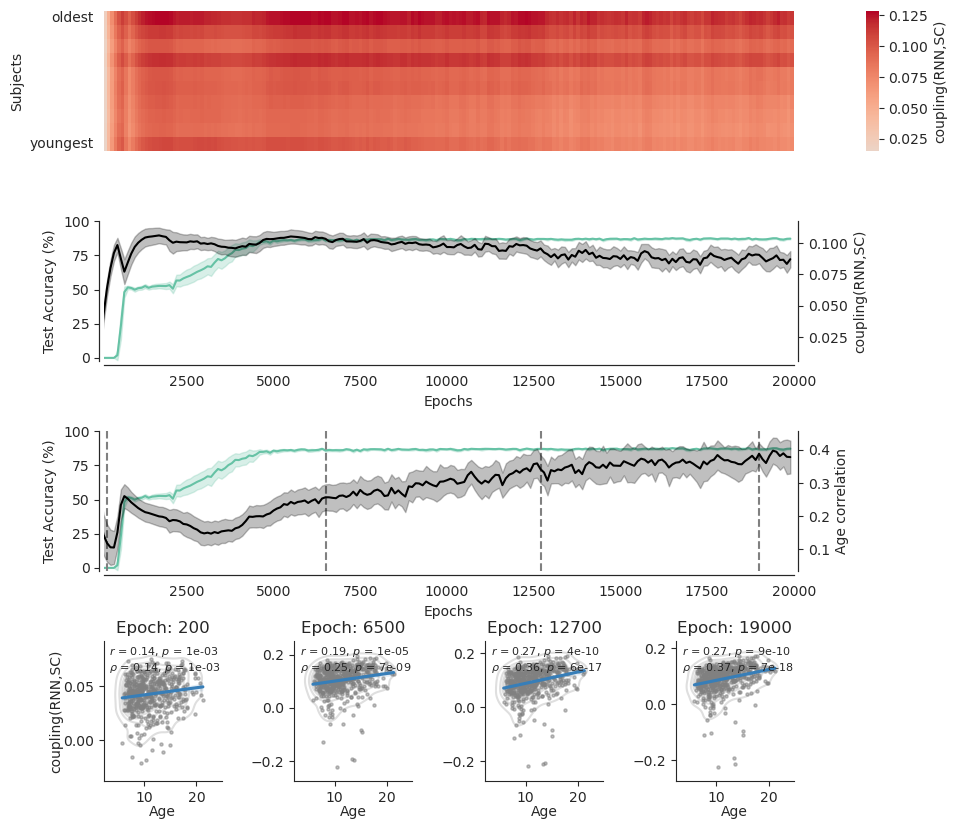

In [20]:
fig_width = 10
fig_height = 10
f = plt.figure(layout=None, figsize=(fig_width, fig_height))
cbar_width = 2.5
column_width = (100 - cbar_width) / 4
gs = f.add_gridspec(nrows=4, ncols=5, hspace=0.5, wspace=0.75,
                    width_ratios=[column_width, column_width, column_width, column_width, cbar_width])
ax0 = f.add_subplot(gs[0, :-1])
ax0_cbar = f.add_subplot(gs[0, -1])
ax1 = f.add_subplot(gs[1, :-1])
ax1_twin = ax1.twinx()
ax2 = f.add_subplot(gs[2, :-1])
ax2_twin = ax2.twinx()

ax3_0 = f.add_subplot(gs[3, 0])
ax3_1 = f.add_subplot(gs[3, 1])
ax3_2 = f.add_subplot(gs[3, 2])
ax3_3 = f.add_subplot(gs[3, 3])
ax3_list = [ax3_0, ax3_1, ax3_2, ax3_3]

color_palette = sns.color_palette("Set2")
x = np.arange(0, n_epochs + x_step, x_step)
# indices = [3, 10, 50, 80]
# indices = [50, 100, 150, 175]
# indices = np.linspace(25, n_logged_epochs-25, 4).astype(int)
indices = np.linspace(2.5, n_logged_epochs-10, 4).astype(int)
print(indices)
n_indices = len(indices)

# row 0
yticklabels = [None] * n_quantiles
yticklabels[0] = 'youngest'
yticklabels[-1] = 'oldest'
sns.heatmap(feature_corr_mean_group.T, ax=ax0, square=False, cmap='coolwarm', center=0, cbar_ax=ax0_cbar, cbar_kws={'label': 'coupling(RNN,SC)'})
# age_idx = np.argsort(df_human['age'])
# sns.heatmap(feature_corr_mean[1:, age_idx].T, ax=ax0, square=False, cmap='coolwarm', center=0, cbar_ax=ax0_cbar, cbar_kws={'label': 'coupling(RNN,A)'})
ax0.set_ylabel('Subjects')
ax0.set_xticklabels('')
ax0.set_yticks(np.arange(n_quantiles))
ax0.set_yticklabels(yticklabels, rotation=0, va='bottom')
ax0.invert_yaxis()

# row 1, 2
# add accuracy to both
accuracy_mean = test_accuracy.mean(axis=0)*100
accuracy_std = test_accuracy.std(axis=0)*100
ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
accuracy_ci_lower = accuracy_mean - ci
accuracy_ci_upper = accuracy_mean + ci
for this_ax in [ax1, ax2]:
    this_ax.plot(x, accuracy_mean, color=color_palette[0])
    this_ax.fill_between(x, accuracy_ci_lower, accuracy_ci_upper, color=color_palette[0], alpha=0.25)
    this_ax.set_ylim([-2.5, 100])
    this_ax.set_xlim([x_start*100, (n_logged_epochs+x_start-1)*100])
    this_ax.set_ylabel('Test Accuracy (%)')
    this_ax.set_xlabel('Epochs')

# row 1
coupling_mean = feature_corr.mean(axis=-1).mean(axis=0)
coupling_std = feature_corr.mean(axis=-1).std(axis=0)
ci = 1.96 * (coupling_std / np.sqrt(n_runs))
ax1_twin.plot(x, coupling_mean, color='k')
ax1_twin.fill_between(x, coupling_mean - ci, coupling_mean + ci, color='k', alpha=0.25)
ax1_twin.set_ylabel('coupling(RNN,SC)')

# row 2
age_corr_std = age_corr.std(axis=0)
ci = 1.96 * (age_corr_std / np.sqrt(n_runs))
ax2_twin.plot(x, age_corr_mean, color='k')
ax2_twin.fill_between(x, age_corr_mean - ci, age_corr_mean + ci, color='k', alpha=0.25)
ax2_twin.set_ylabel('Age correlation')

for this_ax in [ax1, ax1_twin, ax2, ax2_twin]:
    sns.despine(offset=3, trim=False, left=False, right=False, top=True, bottom=False, ax=this_ax)

# row 3
for i, epoch in enumerate(indices):
    if i == 0:
        ylabel = 'coupling(RNN,SC)'
    else:
        ylabel = ''
    my_reg_plot(x=df_human['age'], y=feature_corr_mean[epoch-x_start],
    # my_reg_plot(x=df_human['age'], y=feature_corr[0, epoch-x_start],
                xlabel='Age', ylabel=ylabel, ax=ax3_list[i], annotate='both')
    sns.despine(offset=0, trim=False, left=False, right=True, top=True, bottom=False, ax=ax3_list[i])
    ax3_list[i].set_title('Epoch: {0}'.format(epoch*100))

    # add vertical lines to other plots
    # ax0.axvline(epoch-x_start, color='gray', linestyle='--')
    # ax1.axvline(epoch*100, color='gray', linestyle='--')
    ax2.axvline(epoch*100, color='gray', linestyle='--')

file_str2 = '{0}_corr(RNN_sc,{1}_sc).png'.format(file_str, dataset)
# f.suptitle(file_str2)
plt.show()
f.savefig(os.path.join(outdir, file_str2), dpi=300, bbox_inches='tight', pad_inches=0.01)

In [21]:
# f, ax = plt.subplots(2, 4, figsize=(10, 5))
# # A = np.abs(hidden_weights[0, 50]).copy()
# A = np.abs(hidden_weights[:, 50]).copy()
# if A.ndim == 3:
#     A = np.mean(A, axis=0)
# # A = (A + A.T) / 2
# # A = A / np.linalg.norm(A)
# print(A.shape)
#
# for i, subj in enumerate([0, 100, 200, 300]):
#     my_reg_plot(x=np.mean(rnn_features, axis=0)[50, :], y=human_features[subj, :], xlabel='RNN weights', ylabel='connectome weights', ax=ax[0, i], annotate='both')
#     my_reg_plot(x=bct.strengths_dir(A), y=bct.strengths_und(A_human[:, :, subj]), xlabel='RNN weights', ylabel='connectome weights', ax=ax[1, i], annotate='both')
#
# f.tight_layout()
# plt.show()